# Forecasting with Limited Data

We have **5 data points** spread over 14 years and need to forecast 3–8 years ahead.

We will try three approaches:
1. **Trend Regression** — fit a line through the data and extend it
2. **Scenario Forecasting** — create optimistic, base, and pessimistic futures
3. **External Drivers** — use GDP (more frequent data) to improve the forecast

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS

# Style settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
# Our sparse dataset: 5 observations over 14 years
data = pd.DataFrame({
    'year': [2008, 2011, 2014, 2018, 2022],
    'completion_rate': [42, 51, 58, 67, 72]
})

print("Our data:")
print(data)
print(f"\nTotal observations: {len(data)}")
print(f"Time span: {data['year'].max() - data['year'].min()} years")

Our data:
   year  completion_rate
0  2008               42
1  2011               51
2  2014               58
3  2018               67
4  2022               72

Total observations: 5
Time span: 14 years


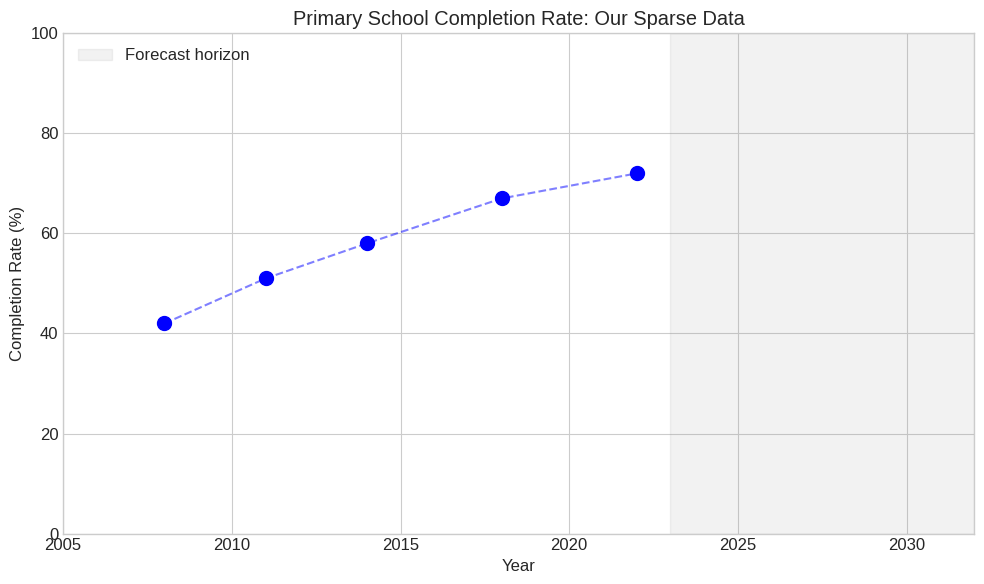

In [3]:
# Visualize what we're working with
plt.figure(figsize=(10, 6))
plt.scatter(data['year'], data['completion_rate'], s=100, color='blue', zorder=5)
plt.plot(data['year'], data['completion_rate'], 'b--', alpha=0.5)
plt.xlabel('Year')
plt.ylabel('Completion Rate (%)')
plt.title('Primary School Completion Rate: Our Sparse Data')
plt.ylim(0, 100)
plt.xlim(2005, 2032)

# Mark the forecast horizon
plt.axvspan(2023, 2032, alpha=0.1, color='gray', label='Forecast horizon')
plt.legend()
plt.tight_layout()
plt.show()

---
## Approach 1: Trend Regression

We fit a line through our 5 data points and extend it into the future. We will try two versions:

- **Linear**: assumes the same growth every year (e.g. +2 percentage points per year forever)
- **Log-linear**: assumes growth *slows down* as the value gets higher — more realistic for percentages near a ceiling

### Part 1a: Linear Trend

**OLS (Ordinary Least Squares)** finds the best straight line through the data — the one that minimizes the total distance between the line and all 5 points.

- **Intercept**: where the line starts (at year = 0, which is far before our data — not meaningful on its own)
- **Slope**: how many percentage points the rate grows *per year*
- **R-squared**: how well the line fits the data (1.0 = perfect fit, 0 = no fit)

In [4]:
# Prepare data for regression
X = sm.add_constant(data['year'])  # Add intercept
y = data['completion_rate']

# Fit linear model
model_linear = OLS(y, X).fit()

print("Linear Model Summary:")
print(f"Intercept: {model_linear.params['const']:.2f}")
print(f"Slope: {model_linear.params['year']:.2f} percentage points per year")
print(f"R-squared: {model_linear.rsquared:.3f}")

Linear Model Summary:
Intercept: -4275.35
Slope: 2.15 percentage points per year
R-squared: 0.979


In [5]:
# Generate forecasts
forecast_years = [2025, 2027, 2030]
all_years = list(data['year']) + forecast_years

X_all = sm.add_constant(all_years)
predictions_linear = model_linear.predict(X_all)

# Show forecast values
print("Linear Trend Forecasts:")
for year, pred in zip(forecast_years, predictions_linear[-3:]):
    print(f"  {year}: {pred:.1f}%")

Linear Trend Forecasts:
  2025: 80.4%
  2027: 84.7%
  2030: 91.1%


### Part 1b: Log-Linear Trend

Growth in percentages naturally slows down near the top — going from 5% to 50% is easier than going from 85% to 90%. The **log transform** captures this pattern automatically.

Instead of fitting `rate = a + b × year`, we fit:  
`rate = a + b × log(years elapsed)`

The log function grows fast at first and slows over time — matching how real-world rates behave.

In [6]:
# Create log-transformed year (offset to avoid log(0))
base_year = 2007  # One year before first observation
data['years_since_base'] = data['year'] - base_year
data['log_years'] = np.log(data['years_since_base'])

# Fit log-linear model
X_log = sm.add_constant(data['log_years'])
model_loglinear = OLS(y, X_log).fit()

print("Log-Linear Model Summary:")
print(f"Intercept: {model_loglinear.params['const']:.2f}")
print(f"Log coefficient: {model_loglinear.params['log_years']:.2f}")
print(f"R-squared: {model_loglinear.rsquared:.3f}")

Log-Linear Model Summary:
Intercept: 39.54
Log coefficient: 10.94
R-squared: 0.936


In [7]:
# Generate log-linear forecasts
all_years_since_base = [yr - base_year for yr in all_years]
all_log_years = np.log(all_years_since_base)
X_log_all = sm.add_constant(all_log_years)
predictions_loglinear = model_loglinear.predict(X_log_all)

print("Log-Linear Trend Forecasts:")
for year, pred in zip(forecast_years, predictions_loglinear[-3:]):
    print(f"  {year}: {pred:.1f}%")

Log-Linear Trend Forecasts:
  2025: 71.2%
  2027: 72.3%
  2030: 73.8%


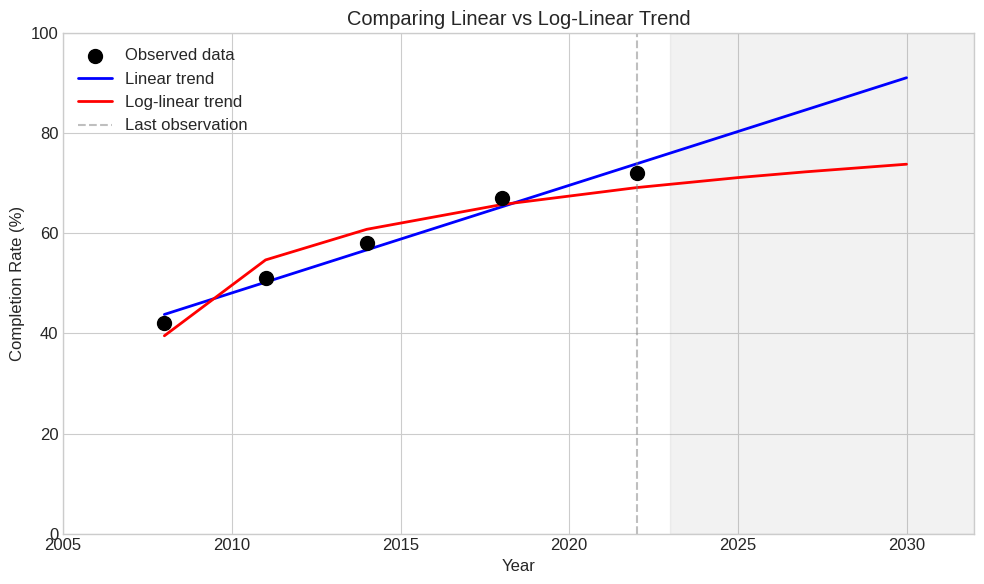


Key difference:
  Linear predicts 91.1% by 2030
  Log-linear predicts 73.8% by 2030

Log-linear is more conservative — growth slows as we approach higher levels


In [8]:
plt.figure(figsize=(10, 6))

# Historical data
plt.scatter(data['year'], data['completion_rate'], s=100, color='black', 
            zorder=5, label='Observed data')

# Linear trend
plt.plot(all_years, predictions_linear, 'b-', linewidth=2, label='Linear trend')

# Log-linear trend
plt.plot(all_years, predictions_loglinear, 'r-', linewidth=2, label='Log-linear trend')

# Forecast horizon
plt.axvspan(2023, 2032, alpha=0.1, color='gray')
plt.axvline(x=2022, color='gray', linestyle='--', alpha=0.5, label='Last observation')

plt.xlabel('Year')
plt.ylabel('Completion Rate (%)')
plt.title('Comparing Linear vs Log-Linear Trend')
plt.ylim(0, 100)
plt.xlim(2005, 2032)
plt.legend()
plt.tight_layout()
plt.show()

print("\nKey difference:")
print(f"  Linear predicts {predictions_linear[-1]:.1f}% by 2030")
print(f"  Log-linear predicts {predictions_loglinear[-1]:.1f}% by 2030")
print("\nLog-linear is more conservative — growth slows as we approach higher levels")

---
## Approach 2: Scenario-Based Forecasting

Instead of one forecast, we produce **three** by adjusting the slope of our log-linear trend:

| Scenario | Slope adjustment | Meaning |
|---|---|---|
| Optimistic | × 1.25 | Growth 25% faster than current trend |
| Base case | × 1.00 | Current trend continues |
| Pessimistic | × 0.70 | Growth 30% slower than current trend |



In [9]:
# Use log-linear as our base model
base_slope = model_loglinear.params['log_years']
base_intercept = model_loglinear.params['const']

# Define scenarios by adjusting the slope
scenarios = {
    'Optimistic': base_slope * 1.25,   # 25% faster growth
    'Base case': base_slope,            # Current trend
    'Pessimistic': base_slope * 0.70   # 30% slower growth
}

print("Scenario slopes (log coefficient):")
for name, slope in scenarios.items():
    print(f"  {name}: {slope:.2f}")

Scenario slopes (log coefficient):
  Optimistic: 13.67
  Base case: 10.94
  Pessimistic: 7.66


In [10]:
# Generate forecasts for each scenario
scenario_forecasts = {}

for name, slope in scenarios.items():
    # Recalculate intercept to pass through 2022 observed value
    last_log_year = np.log(2022 - base_year)
    adjusted_intercept = 72 - slope * last_log_year  # Anchor to last observation
    
    forecasts = adjusted_intercept + slope * all_log_years
    scenario_forecasts[name] = forecasts

# Print forecast values
print("\nScenario Forecasts:")
print("-" * 50)
print(f"{'Year':<10}{'Pessimistic':<15}{'Base':<15}{'Optimistic':<15}")
print("-" * 50)
for i, year in enumerate(forecast_years):
    idx = len(data) + i
    print(f"{year:<10}{scenario_forecasts['Pessimistic'][idx]:<15.1f}{scenario_forecasts['Base case'][idx]:<15.1f}{scenario_forecasts['Optimistic'][idx]:<15.1f}")


Scenario Forecasts:
--------------------------------------------------
Year      Pessimistic    Base           Optimistic     
--------------------------------------------------
2025      73.4           74.0           74.5           
2027      74.2           75.1           75.9           
2030      75.3           76.7           77.8           


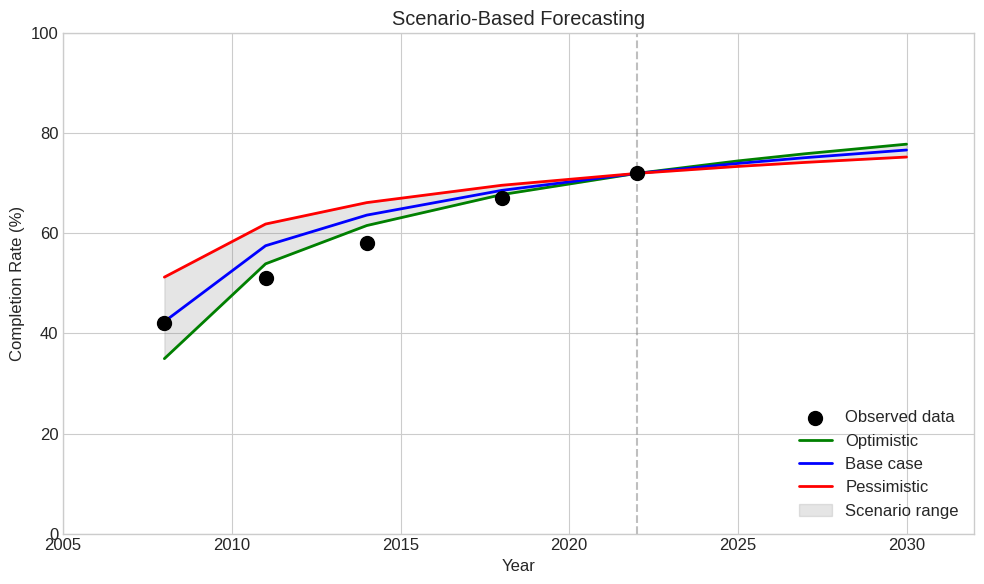

In [11]:
# Visualize scenarios
plt.figure(figsize=(10, 6))

# Historical data
plt.scatter(data['year'], data['completion_rate'], s=100, color='black', 
            zorder=5, label='Observed data')

# Scenario lines
colors = {'Optimistic': 'green', 'Base case': 'blue', 'Pessimistic': 'red'}
for name, forecasts in scenario_forecasts.items():
    plt.plot(all_years, forecasts, color=colors[name], linewidth=2, label=name)

# Shade between optimistic and pessimistic
plt.fill_between(all_years, 
                 scenario_forecasts['Pessimistic'], 
                 scenario_forecasts['Optimistic'],
                 alpha=0.2, color='gray', label='Scenario range')

# Forecast horizon
plt.axvline(x=2022, color='gray', linestyle='--', alpha=0.5)

plt.xlabel('Year')
plt.ylabel('Completion Rate (%)')
plt.title('Scenario-Based Forecasting')
plt.ylim(0, 100)
plt.xlim(2005, 2032)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Approach 3: External Driver (GDP)

Our completion rate has only 5 data points. GDP per capita is recorded every year — 15 points over the same period.  
Since they are correlated, we can use GDP as a predictor to get a stronger forecast.


In [12]:
# Simulate having annual GDP data (more frequent than our completion rate)
gdp_data = pd.DataFrame({
    'year': list(range(2008, 2023)),
    'gdp_per_capita': [450, 470, 495, 520, 550, 590, 640, 700, 750, 
                       810, 870, 950, 1020, 1100, 1180]
})

print("GDP data (annual - 15 observations):")
print(gdp_data.head(10))
print("...")

GDP data (annual - 15 observations):
   year  gdp_per_capita
0  2008             450
1  2009             470
2  2010             495
3  2011             520
4  2012             550
5  2013             590
6  2014             640
7  2015             700
8  2016             750
9  2017             810
...


In [13]:
# Merge with our completion rate data
merged_data = data.merge(gdp_data, on='year', how='left')
print("Merged data:")
print(merged_data[['year', 'completion_rate', 'gdp_per_capita']])

Merged data:
   year  completion_rate  gdp_per_capita
0  2008               42             450
1  2011               51             520
2  2014               58             640
3  2018               67             870
4  2022               72            1180


  CORRELATION RESULT:  0.943
  Scale:  -1 = perfectly opposite
           0 = no relationship at all
          +1 = perfectly in sync

  Our value (0.943) is very close to +1
  → When GDP goes up, completion rate goes up too
  → GDP is a valid predictor for our model


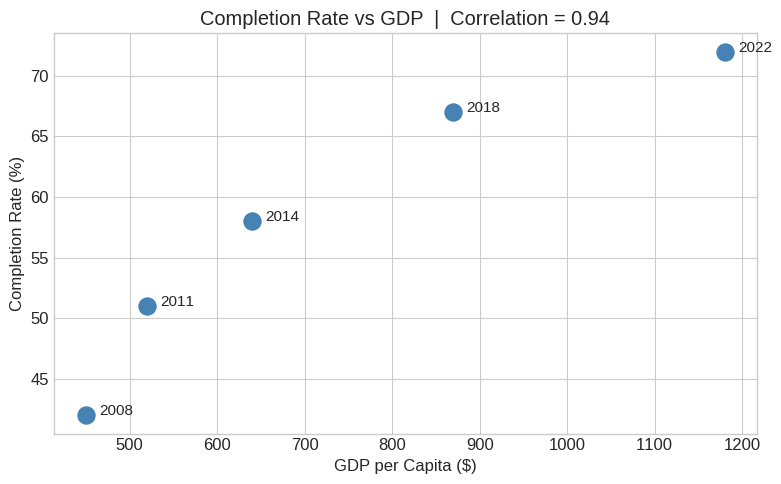

In [14]:
# Step 1: Calculate and display correlation clearly
correlation = merged_data['completion_rate'].corr(merged_data['gdp_per_capita'])

print("=" * 50)
print(f"  CORRELATION RESULT:  {correlation:.3f}")
print("=" * 50)
print("  Scale:  -1 = perfectly opposite")
print("           0 = no relationship at all")
print("          +1 = perfectly in sync")
print(f"\n  Our value ({correlation:.3f}) is very close to +1")
print("  → When GDP goes up, completion rate goes up too")
print("  → GDP is a valid predictor for our model")
print("=" * 50)

# Step 2: Visualize the relationship
plt.figure(figsize=(8, 5))
plt.scatter(merged_data['gdp_per_capita'], merged_data['completion_rate'], 
            s=150, color='steelblue', zorder=5)
for i, row in merged_data.iterrows():
    plt.annotate(int(row['year']), 
                 (row['gdp_per_capita'] + 15, row['completion_rate']),
                 fontsize=11)
plt.xlabel('GDP per Capita ($)')
plt.ylabel('Completion Rate (%)')
plt.title(f'Completion Rate vs GDP  |  Correlation = {correlation:.2f}')
plt.tight_layout()
plt.show()

In [15]:
# Fit model with GDP ONLY (not year + GDP together)
X_gdp = sm.add_constant(merged_data['gdp_per_capita'])
model_with_gdp = OLS(merged_data['completion_rate'], X_gdp).fit()

print("Model with GDP as Driver:")
print(f"Intercept:       {model_with_gdp.params['const']:.2f}")
print(f"GDP coefficient: {model_with_gdp.params['gdp_per_capita']:.4f}")
print(f"R-squared:       {model_with_gdp.rsquared:.3f}")
print(f"\nInterpretation: Every $1 rise in GDP per capita is associated with")
print(f"+{model_with_gdp.params['gdp_per_capita']:.4f} percentage points in completion rate")

Model with GDP as Driver:
Intercept:       29.96
GDP coefficient: 0.0383
R-squared:       0.889

Interpretation: Every $1 rise in GDP per capita is associated with
+0.0383 percentage points in completion rate


This is projecting future GDP values. We know GDP in 2022 was $1,180. We do not have future GDP data — so we assume it keeps growing at 7% per year and calculate what it would be in 2025, 2027, and 2030.

The formula: compound growth
It works exactly like compound interest in a bank account.

future value = current value × (1 + growth rate) ^ number of years

1.07 means "grow by 7%" → 1.00 (keep what you have) + 0.07 (add 7%)


In [16]:
# Forecast using projected GDP (assuming 7% annual GDP growth)
future_gdp = {
    2025: 1180 * (1.07 ** 3),
    2027: 1180 * (1.07 ** 5),
    2030: 1180 * (1.07 ** 8)
}

intercept = model_with_gdp.params['const']
slope     = model_with_gdp.params['gdp_per_capita']

print("Projected GDP per capita:")
for year, gdp in future_gdp.items():
    print(f"  {year}: ${gdp:.0f}")

print("\nForecasts using GDP driver:")
print("-" * 60)
for year, gdp in future_gdp.items():
    X_new  = pd.DataFrame({'const': [1], 'gdp_per_capita': [gdp]})
    pred   = model_with_gdp.predict(X_new)[0]
    formula = f"{intercept:.1f} + {slope:.4f} × {gdp:.0f}"
    flag   = "  ⚠️  OVER 100% — impossible!" if pred > 100 else ""
    print(f"  {year}: {formula} = {pred:.1f}%{flag}")

print("-" * 60)
print("\n⚠️  WHY DOES 2030 EXCEED 100%?")
print("   The model is a straight line:  rate = 29.96 + 0.038 × GDP")
print("   A straight line has NO ceiling — it can grow forever.")
print("   But a percentage CANNOT go above 100%.")
print()
print("   This is the core limitation of linear models for bounded variables.")
print("   Quick fix → cap at 100%.  Proper fix → use a logit-transformed model.")
print()
gdp_at_100 = (100 - intercept) / slope
print(f"   The model hits 100% when GDP = ${gdp_at_100:.0f}")
print(f"   Our 2030 GDP projection (${future_gdp[2030]:.0f}) already exceeds that.")

Projected GDP per capita:
  2025: $1446
  2027: $1655
  2030: $2027

Forecasts using GDP driver:
------------------------------------------------------------
  2025: 30.0 + 0.0383 × 1446 = 85.3%
  2027: 30.0 + 0.0383 × 1655 = 93.4%
  2030: 30.0 + 0.0383 × 2027 = 107.6%  ⚠️  OVER 100% — impossible!
------------------------------------------------------------

⚠️  WHY DOES 2030 EXCEED 100%?
   The model is a straight line:  rate = 29.96 + 0.038 × GDP
   A straight line has NO ceiling — it can grow forever.
   But a percentage CANNOT go above 100%.

   This is the core limitation of linear models for bounded variables.
   Quick fix → cap at 100%.  Proper fix → use a logit-transformed model.

   The model hits 100% when GDP = $1828
   Our 2030 GDP projection ($2027) already exceeds that.


In [17]:
# Get confidence intervals from the log-linear model
X_forecast = sm.add_constant(all_log_years)
predictions = model_loglinear.get_prediction(X_forecast)

# Extract prediction summary
pred_summary = predictions.summary_frame(alpha=0.05)  # 95% CI
pred_summary['year'] = all_years

print("Predictions with 95% Confidence Intervals:")
print(pred_summary[['year', 'mean', 'mean_ci_lower', 'mean_ci_upper']].tail(8))

Predictions with 95% Confidence Intervals:
   year       mean  mean_ci_lower  mean_ci_upper
0  2008  39.538058      29.337734      49.738383
1  2011  54.703519      49.439140      59.967898
2  2014  60.825473      55.624833      66.026113
3  2018  65.769995      59.511733      72.028256
4  2022  69.162955      61.812711      76.513199
5  2025  71.157474      63.079897      79.235052
6  2027  72.310073      63.791217      80.828928
7  2030  73.839008      64.715729      82.962286


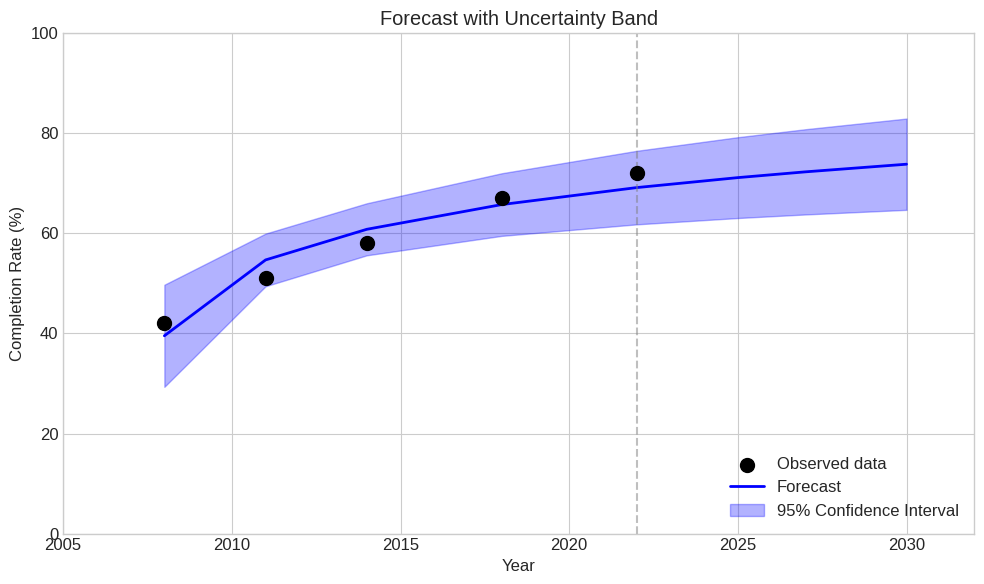


Notice how the confidence band widens as we forecast further into the future.
This is honest — we are less certain about predictions further away.


In [18]:
# Visualize with confidence bands
plt.figure(figsize=(10, 6))

# Historical data
plt.scatter(data['year'], data['completion_rate'], s=100, color='black', 
            zorder=5, label='Observed data')

# Forecast line
plt.plot(all_years, pred_summary['mean'], 'b-', linewidth=2, label='Forecast')

# Confidence band
plt.fill_between(all_years, 
                 pred_summary['mean_ci_lower'], 
                 pred_summary['mean_ci_upper'],
                 alpha=0.3, color='blue', label='95% Confidence Interval')

# Forecast horizon marker
plt.axvline(x=2022, color='gray', linestyle='--', alpha=0.5)

plt.xlabel('Year')
plt.ylabel('Completion Rate (%)')
plt.title('Forecast with Uncertainty Band')
plt.ylim(0, 100)
plt.xlim(2005, 2032)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("\nNotice how the confidence band widens as we forecast further into the future.")
print("This is honest — we are less certain about predictions further away.")

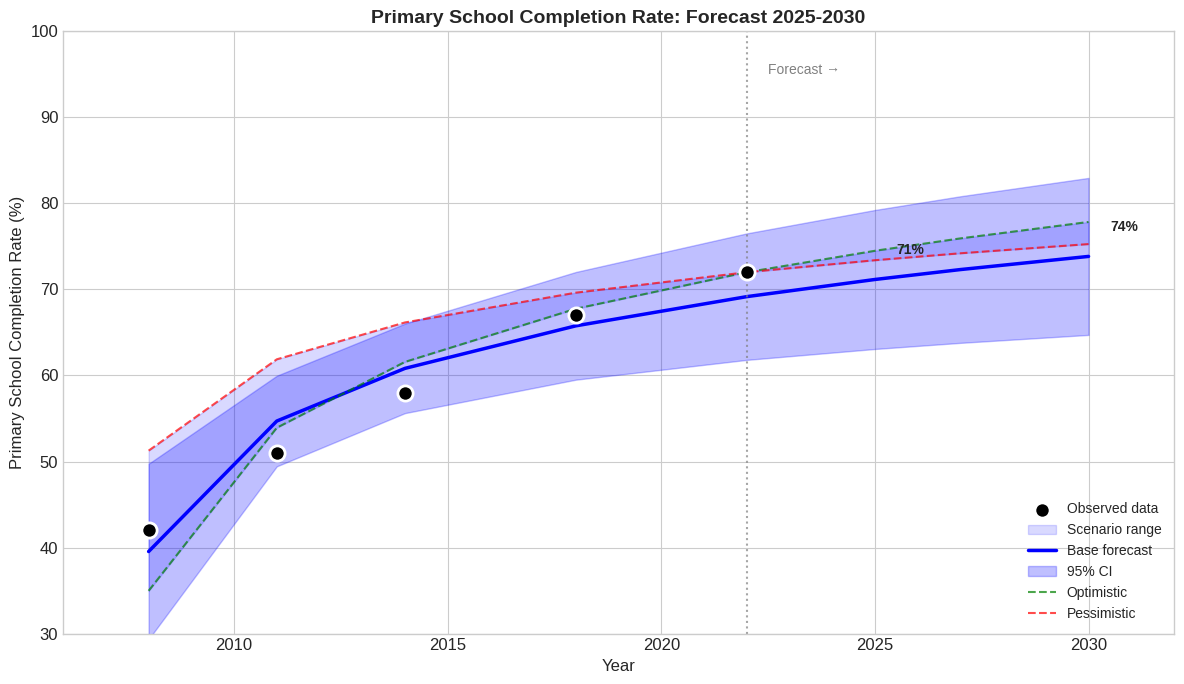

In [19]:
fig, ax = plt.subplots(figsize=(12, 7))

# Historical data
ax.scatter(data['year'], data['completion_rate'], s=120, color='black', 
           zorder=5, label='Observed data', edgecolors='white', linewidths=2)

# Scenario range (shaded)
ax.fill_between(all_years, 
                scenario_forecasts['Pessimistic'], 
                scenario_forecasts['Optimistic'],
                alpha=0.15, color='blue', label='Scenario range')

# Base case with confidence interval
ax.plot(all_years, pred_summary['mean'], 'b-', linewidth=2.5, label='Base forecast')
ax.fill_between(all_years, 
                pred_summary['mean_ci_lower'], 
                pred_summary['mean_ci_upper'],
                alpha=0.25, color='blue', label='95% CI')

# Scenario lines (dashed)
ax.plot(all_years, scenario_forecasts['Optimistic'], 'g--', 
        linewidth=1.5, alpha=0.7, label='Optimistic')
ax.plot(all_years, scenario_forecasts['Pessimistic'], 'r--', 
        linewidth=1.5, alpha=0.7, label='Pessimistic')

# Forecast horizon
ax.axvline(x=2022, color='gray', linestyle=':', alpha=0.7)
ax.text(2022.5, 95, 'Forecast →', fontsize=10, color='gray')

# Formatting
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Primary School Completion Rate (%)', fontsize=12)
ax.set_title('Primary School Completion Rate: Forecast 2025-2030', fontsize=14, fontweight='bold')
ax.set_ylim(30, 100)
ax.set_xlim(2006, 2032)
ax.legend(loc='lower right', fontsize=10)

# Add forecast values as annotations
for year in [2025, 2030]:
    idx = all_years.index(year)
    base_val = pred_summary['mean'].iloc[idx]
    ax.annotate(f'{base_val:.0f}%', 
                xy=(year, base_val), 
                xytext=(year + 0.5, base_val + 3),
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()